#### Setup & Import Modules

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import BASE_DIR, REGIONS
from src.data_loader import load_traceability_data, validate_and_enrich_data
from src.utils import get_region_summary, get_compliance_summary, filter_for_eu_market

print("Setup Complete")
print(f"Project Root: {BASE_DIR}")

Traceability & Responsible Sourcing Config loaded successfully!
Project Root: C:\Users\tohiba\Desktop\traceability-responsible-sourcing-map
Setup Complete
Project Root: C:\Users\tohiba\Desktop\traceability-responsible-sourcing-map


#### Load and Validate Data

In [2]:
df = load_traceability_data()
df = validate_and_enrich_data(df)

print(f"Loaded {len(df)} lots")
print(f"EUDR Compliant Rate : {df['eudr_compliant'].mean()*100:.1f}%")
print(f"Average SCA Score   : {df['sca_score'].mean():.2f}")

Loaded 50 lots from processed pickle file
Loaded 50 lots
EUDR Compliant Rate : 84.0%
Average SCA Score   : 87.90


#### EUDR Compliance & Risk Analysis

=== EUDR COMPLIANCE & DEFORESTATION RISK ===



lot_id sca_score       available_quantity_kg eudr_compliant
                   count      mean   max                   sum            sum
compliance_status                                                            
At Risk                1     82.20  82.2                4260.0              1
Compliant             43     88.15  92.8              247860.0             37
In Progress            6     87.03  91.7               38640.0              4

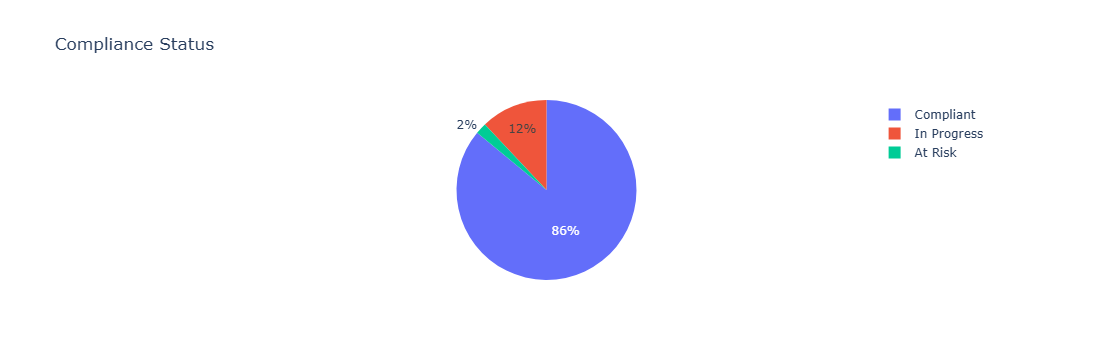


Deforestation Risk Distribution:
deforestation_risk
Low       38
Medium     8
High       4
Name: count, dtype: int64


In [3]:
print("=== EUDR COMPLIANCE & DEFORESTATION RISK ===\n")

display(get_compliance_summary(df))

fig = px.pie(df, names='compliance_status', title="Compliance Status")
fig.show()

print("\nDeforestation Risk Distribution:")
print(df['deforestation_risk'].value_counts())

#### Regional Deep Analysis

=== REGIONAL PERFORMANCE ANALYSIS ===



sca_score             eudr_compliant deforestation_risk  \
                 mean   max count            sum           <lambda>   
region                                                                
Guji            88.51  92.1    13             13                 10   
Limmu           87.35  92.8    15             10                 11   
Sidama          88.22  92.2    11              9                  8   
Yirgacheffe     87.61  92.8    11             10                  9   

            available_quantity_kg farmer_premium_usd  
                              sum               mean  
region                                                
Guji                      84660.0               0.60  
Limmu                     78660.0               0.63  
Sidama                    62280.0               0.59  
Yirgacheffe               65160.0               0.54

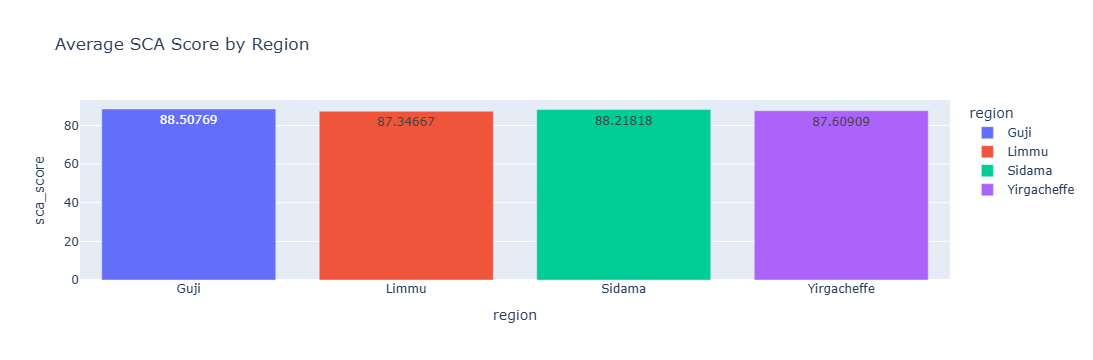

In [4]:
print("=== REGIONAL PERFORMANCE ANALYSIS ===\n")

region_summary = get_region_summary(df)
display(region_summary)

fig = px.bar(
    df.groupby('region')['sca_score'].mean().reset_index(),
    x='region', y='sca_score',
    title="Average SCA Score by Region",
    color='region',
    text_auto=True
)
fig.show()

#### Traceability Level Analysis

In [5]:
print("=== TRACEABILITY LEVEL ANALYSIS ===\n")

trace_summary = df.groupby('traceability_level').agg({
    'lot_id': 'count',
    'sca_score': 'mean',
    'eudr_compliant': 'sum',
    'available_quantity_kg': 'sum'
}).round(2)

display(trace_summary)

=== TRACEABILITY LEVEL ANALYSIS ===



,lot_id,sca_score,eudr_compliant,available_quantity_kg
traceability_level,,,,
Exporter,4,88.75,4,24480.0
Full Farm,32,87.96,26,190020.0
Washing Station,14,87.52,12,76260.0


#### Top Lots for EU Market

In [6]:
print("=== TOP LOTS RECOMMENDED FOR EU MARKET ===\n")

eu_ready = filter_for_eu_market(df)
top_lots = eu_ready.nlargest(10, 'sca_score')[[
    'lot_id', 'region', 'supplier_name', 'sca_score', 
    'traceability_level', 'sustainability_cert', 
    'deforestation_risk', 'price_per_kg_usd'
]]

display(top_lots)

=== TOP LOTS RECOMMENDED FOR EU MARKET ===



,lot_id,region,supplier_name,sca_score,traceability_level,sustainability_cert,deforestation_risk,price_per_kg_usd
13,ETH-2025-LIM-014,Limmu,Misty Valley,92.5,Full Farm,None,Low,7.80
18,ETH-2025-LIM-019,Limmu,Sidama Crown,92.4,Full Farm,None,Low,6.18
10,ETH-2025-SID-011,Sidama,Guji Highland,92.2,Full Farm,Volcafe Verified,Medium,9.31
42,ETH-2025-GUJ-043,Guji,Sidama Crown,92.0,Full Farm,Volcafe Verified,Low,9.51
49,ETH-2025-GUJ-050,Guji,Misty Valley,91.9,Full Farm,Rainforest Alliance,Low,6.68
23,ETH-2025-GUJ-024,Guji,Daye Bensa,91.7,Full Farm,Volcafe Verified,Low,6.17
11,ETH-2025-SID-012,Sidama,Guji Highland,91.5,Washing Station,Rainforest Alliance,Low,8.37
5,ETH-2025-YIR-006,Yirgacheffe,Red Cherry Export,91.2,Exporter,Rainforest Alliance,Low,6.23
17,ETH-2025-GUJ-018,Guji,Hambela Coffee,90.9,Full Farm,Organic,Low,8.35
9,ETH-2025-GUJ-010,Guji,Sidama Crown,90.7,Full Farm,Volcafe Verified,Low,8.58


#### Key Insights & Recommendations

In [7]:
print("=== KEY INSIGHTS FOR VOLCAFE SPECIALTY SOURCING ===\n")

print(f"1. Total Lots Analyzed               : {len(df)}")
print(f"2. EUDR Compliant Lots               : {df['eudr_compliant'].sum()} / {len(df)} ({df['eudr_compliant'].mean()*100:.1f}%)")
print(f"3. Average SCA Score                 : {df['sca_score'].mean():.2f}")
print(f"4. Best Performing Region            : Guji ({df.groupby('region')['sca_score'].mean().max():.2f})")
print(f"5. Strongest Traceability            : Full Farm = {(df['traceability_level'] == 'Full Farm').sum()} lots")
print(f"6. Low Deforestation Risk            : {(df['deforestation_risk'] == 'Low').sum()} lots ({(df['deforestation_risk'] == 'Low').mean()*100:.1f}%)")
print(f"7. Lots Ready for EU Market          : {len(filter_for_eu_market(df))}")

print("\n--- Strategic Recommendations ---")
print("• Guji is currently the strongest region — prioritize sourcing here for high scores")
print("• Excellent Full Farm traceability coverage (32 lots) — ideal for premium EU clients")
print("• Strong EUDR compliance (84%) — good foundation, focus on converting the 6 'In Progress' lots")
print("• Multiple outstanding lots (92+) with Low Deforestation Risk and Full Farm traceability")
print("• Continue building relationships with Misty Valley, Sidama Crown, and Guji Highland")
print("• Opportunity to promote Volcafe Verified and Rainforest Alliance certified lots")

=== KEY INSIGHTS FOR VOLCAFE SPECIALTY SOURCING ===

1. Total Lots Analyzed               : 50
2. EUDR Compliant Lots               : 42 / 50 (84.0%)
3. Average SCA Score                 : 87.90
4. Best Performing Region            : Guji (88.51)
5. Strongest Traceability            : Full Farm = 32 lots
6. Low Deforestation Risk            : 38 lots (76.0%)
7. Lots Ready for EU Market          : 27

--- Strategic Recommendations ---
• Guji is currently the strongest region — prioritize sourcing here for high scores
• Excellent Full Farm traceability coverage (32 lots) — ideal for premium EU clients
• Strong EUDR compliance (84%) — good foundation, focus on converting the 6 'In Progress' lots
• Multiple outstanding lots (92+) with Low Deforestation Risk and Full Farm traceability
• Continue building relationships with Misty Valley, Sidama Crown, and Guji Highland
• Opportunity to promote Volcafe Verified and Rainforest Alliance certified lots
